In [36]:
!pip install datasets
!pip install librosa
!pip install torch torchvision torchaudio

In [42]:
!pip install torchcodec

In [38]:
from datasets import load_dataset, Audio
import librosa
from IPython.display import Audio
import random
import datasets

# config giống pipeline
TARGET_SR = 16000
MAX_DURATION = 4

In [39]:
ds = load_dataset(
    "thucdangvan020999/speaker_identification_100_speakers_",
    "speaker_001",
    split="train"
)

# convert về 16kHz
ds = ds.cast_column("audio", datasets.Audio(sampling_rate=TARGET_SR))

print(ds)

Dataset({
    features: ['audio', 'speaker_id', 'speaker_index', 'file_name'],
    num_rows: 20
})


In [43]:
print(ds.column_names)

['audio', 'speaker_id', 'speaker_index', 'file_name']


In [48]:
print(ds[0]) 

ImportError: To support decoding audio data, please install 'torchcodec'.

In [ ]:
def preprocess(audio, sr):
    # trim silence
    audio, _ = librosa.effects.trim(audio, top_db=20)

    # normalize
    audio = librosa.util.normalize(audio)

    # fix length (3s)
    max_len = TARGET_SR * MAX_DURATION
    if len(audio) > max_len:
        audio = audio[:max_len]

    return audio

In [ ]:
idx = random.randint(0, len(ds) - 1)
sample = ds[idx]

raw_audio = sample["audio"]["array"]
sr = sample["audio"]["sampling_rate"]

processed_audio = preprocess(raw_audio, sr)

print("Original length:", len(raw_audio))
print("Processed length:", len(processed_audio))

ImportError: To support decoding audio data, please install 'torchcodec'.

In [ ]:
Audio(raw_audio, rate=sr)

NameError: name 'raw_audio' is not defined

In [ ]:
Audio(processed_audio, rate=sr)

### Chuyển audio ---> Spectrogram


In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
# Tính STFT (Short-Time Fourier Transform)
S = librosa.stft(raw_audio)

# Chuyển biên độ sang dB để dễ nhìn
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

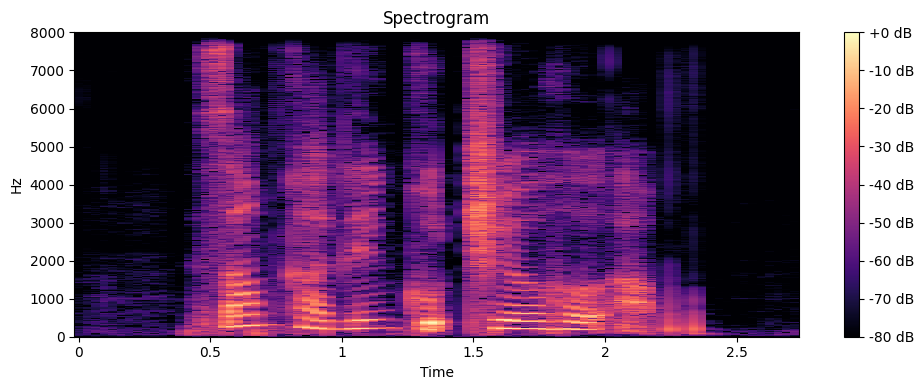

In [ ]:
# Vẽ spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.tight_layout()
plt.show()